In [1]:
import os

import numpy as np
import euler_disk as ed
import matplotlib.pyplot as plt

# Notebook Data Analysis of Euler Disk
Note: This is the single file version of the data analysis notebook, intended to perform analysis of all of the experimental data in every run.

## Input Data Folder
Under this folder are all the wav files.

In [2]:
input_dir = "../data/wav/recording_04.wav"
output_dir = "../data/output/recording_04/"
os.makedirs(output_dir, exist_ok=True)

## Step 1: Welch's Method
We must find the overall frequency contents of our signal and find the harmonics of the fundamental frequncy to then later do a correct bandpass filtering for further processing.
First we perform an stimation of the power spectral density, computing the overall frequency contents of our signal over the recorded time.

In [3]:
window_size=4096
hop_size=1024

ed.welch(input_path=input_dir, output_dir=output_dir, window_size=window_size, hop_size=hop_size)

/home/roldan/EulerDisk/src/euler_disk/data_processing.py:148: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, data = wavfile.read(input_path)


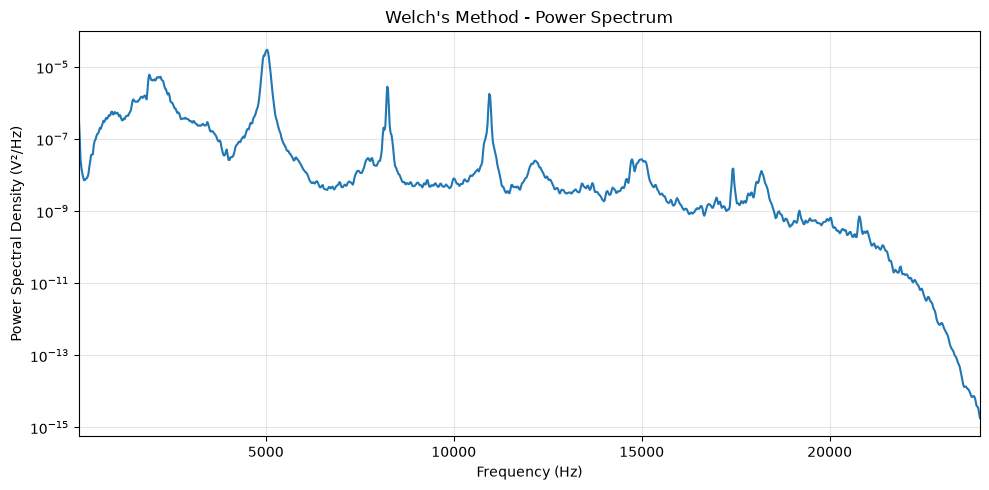

In [4]:
data_welch = np.load(f"{output_dir}/data_welch.npz")
freq, power = data_welch["frequencies"], data_welch["power"]

f_min, f_max = 20, 24000

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(freq, power)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density (V²/Hz)")
ax.set_title("Welch's Method - Power Spectrum")
ax.set_xlim(f_min, f_max)
ax.grid(True, which="both", alpha=0.3)

fig.tight_layout()
plt.show()

## Step 2: Identify Harmonic's Peaks
We use our own function that uses scipy.find_peaks to find the exact first harmonics and then choose our bandpass for AM processing.

In [ ]:
peaks = ed.peaks(
    input_path=f"{output_dir}/data_welch.npz",
    output_dir=f"{output_dir}",
    prominence=6,   # dB
    distance=2,     # bins (~47 Hz at Δf≈23.4 Hz)
)

n = len(peaks["frequencies"])
print(f"\nFound {n} peaks:\n")
print(f"{'Frequency (Hz)':<18} {'Power (V²/Hz)':<18} {'Prominence (dB)':<18}")
print("-" * 54)

freqs = peaks["frequencies"]
powers = peaks["powers"]
proms = peaks.get("prominences", [None] * n)

for f, p, pr in zip(freqs, powers, proms):
    prom_str = f"{pr:<18.2f}" if pr is not None else f"{'—':<18}"
    print(f"{f:<18.2f} {p:<18.3e} {prom_str}")


Found 8 peaks:

Frequency (Hz)     Power (V²/Hz)      Prominence (dB)   
------------------------------------------------------
1898.44            6.176e-06          23.74             
5039.06            3.030e-05          36.22             
8226.56            2.862e-06          28.64             
10945.31           1.805e-06          26.18             
12164.06           2.541e-08          9.04              
15000.00           2.769e-08          11.68             
17437.50           1.529e-08          13.10             
18187.50           1.303e-08          9.46              


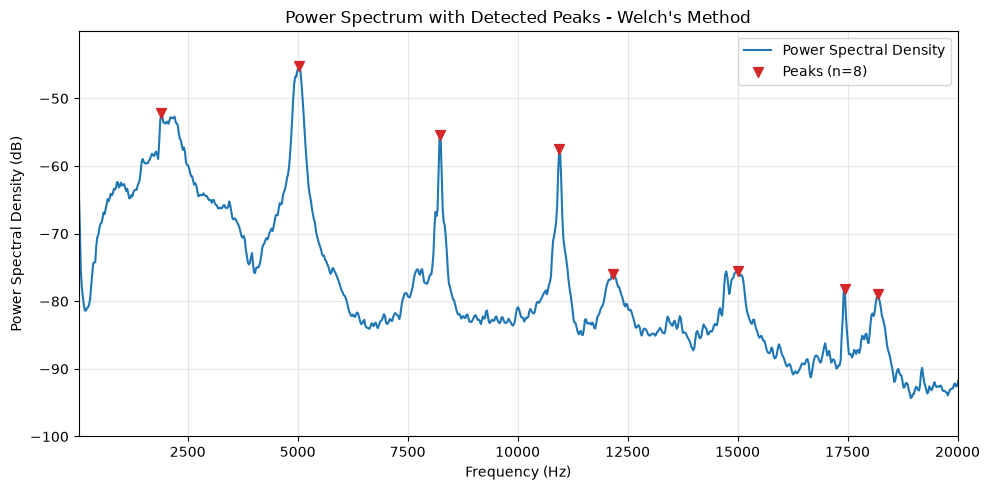

In [13]:
peak_data = np.load(f"{output_dir}/peak_data.npz")

welch_db = 10 * np.log10(data_welch["power"] + 1e-20)
peak_db = 10 * np.log10(peak_data["powers"] + 1e-20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_yscale("linear")
ax.plot(data_welch["frequencies"], welch_db, label="Power Spectral Density", color="tab:blue")
ax.scatter(peak_data["frequencies"], peak_db, color="tab:red", s=50, marker="v", label=f"Peaks (n={len(peak_data['frequencies'])})", zorder=5)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density (dB)")
ax.set_title("Power Spectrum with Detected Peaks - Welch's Method")
ax.grid(True, which="both", alpha=0.3)
ax.set_xlim(f_min, 20000)
ax.set_ylim(-100)
ax.legend()
fig.tight_layout()
plt.show()

# Step 3: Bandpass Filtering
We then apply a bandpass filter to isolate the most prominent peak from last step.

In [14]:
i = np.argmax(peak_data["prominences"])
f_peak = peak_data["frequencies"][i]